# Advanced Resilient Credit Pipeline: GAIN · Boruta-SHAP · TabNet + Monotonic XGBoost · SHAP + DiCE
### Ensemble ML for Resilient Financial Decisions · IndabaX Eswatini 2026

In this notebook we build a complete credit-decision pipeline, starting from a raw loan-application dataset and ending with a model whose decisions can be explained, questioned, and executed.

## The data

We work with `Loan.csv`, a dataset of 20,000 historical loan applications. Each row is one applicant as they stood at the moment they applied with features: age, income, employment status, existing debt, assets and liabilities, credit history, and a handful of derived financial ratios together with the eventual outcome, `LoanApproved`.

It's a realistic stand-in for what a lender actually has to work with: mostly clean, but with real work still required to get it decision-ready, and a couple of columns that look useful but would quietly leak the answer if handled carelessly.



## 1.1  Setup

We install the extra libraries this pipeline needs beyond Colab's defaults: `pytorch-tabnet` for the deep tabular model, `dice-ml` for counterfactual explanations, and `shap` for explainability, alongside `xgboost` and `scikit-learn`. Everything else (PyTorch, pandas, matplotlib) is already available in the Colab runtime.

Once installed, we load the dataset and fix the random seeds for NumPy and PyTorch so that every run of this notebook is reproducible rather than shifting each time we re-run it.

In [ ]:
!pip install pytorch-tabnet
!pip install dice-ml
!pip install shap
!pip install xgboost
!pip install scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import time

np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv("Kaggle_Loan_Data.csv")

## 1.2 Exploratory Data Analysis

Before doing anything, it's worth spending a few minutes actually looking at the data, confirming the target is usable, spotting which fields are skewed enough to need attention later, and getting a first, honest read on which features look related to the outcome before any model tells us so.

We check four things here: how imbalanced `LoanApproved` is, what the shape of the key numeric fields looks like, whether approval rates differ meaningfully across the categorical fields, and how strongly each numeric field correlates with the outcome.

In [ ]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2007/04/25,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2009/11/05,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2016/10/19,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2013/08/13,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2007/03/27,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179141,0.070210,1,36.0


In [ ]:
print(df.shape)

(20000, 36)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])

In [ ]:
df["ApplicationDate"].dtype

dtype('<M8[ns]')

In [ ]:
df["ApplicationDate"].dt.year

,ApplicationDate
0,2007
1,2009
2,2016
3,2013
4,2007
...,...
19995,2014
19996,2009
19997,2022
19998,2005


In [ ]:
df.isna().sum().sum()

np.int64(0)

LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


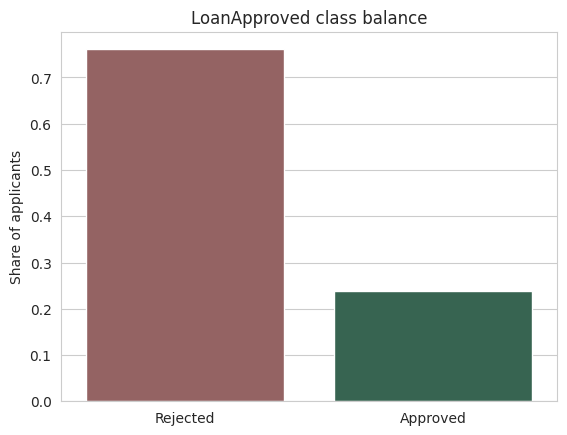

In [ ]:
approval_rate = df["LoanApproved"].value_counts(normalize=True)
print(approval_rate)

sns.set_style("whitegrid")
ax = sns.countplot(data=df, x="LoanApproved", hue="LoanApproved",
                    palette={0: "#9C5B5B", 1: "#2F6B52"}, stat="proportion", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Rejected", "Approved"])
ax.set_title("LoanApproved class balance")
ax.set_ylabel("Share of applicants")
ax.set_xlabel("")
plt.show()

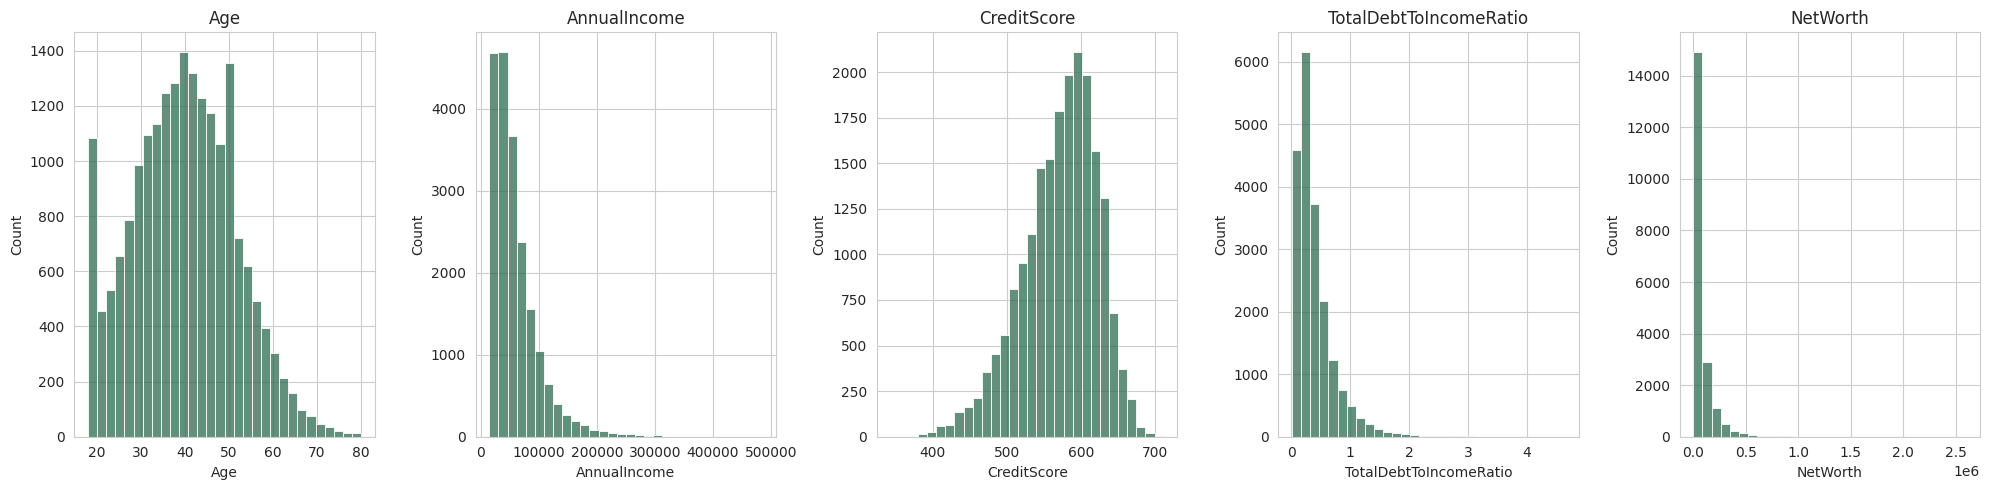

In [ ]:
numeric_preview = ["Age", "AnnualIncome", "CreditScore", "TotalDebtToIncomeRatio", "NetWorth"]

fig, axes = plt.subplots(1, len(numeric_preview), figsize=(20, 5))
for ax, col in zip(axes, numeric_preview):
    sns.histplot(df[col], bins=30, color="#2F6B52", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
categorical_preview = ["EmploymentStatus", "EducationLevel", "HomeOwnershipStatus"]

for col in categorical_preview:
    print(df.groupby(col)["LoanApproved"].mean().sort_values(ascending=False))
    print()

EmploymentStatus
Self-Employed    0.278449
Employed         0.240021
Unemployed       0.181884
Name: LoanApproved, dtype: float64

EducationLevel
Doctorate      0.440252
Master         0.350820
Bachelor       0.266435
Associate      0.204264
High School    0.144381
Name: LoanApproved, dtype: float64

HomeOwnershipStatus
Mortgage    0.251543
Own         0.248857
Rent        0.227698
Other       0.204813
Name: LoanApproved, dtype: float64



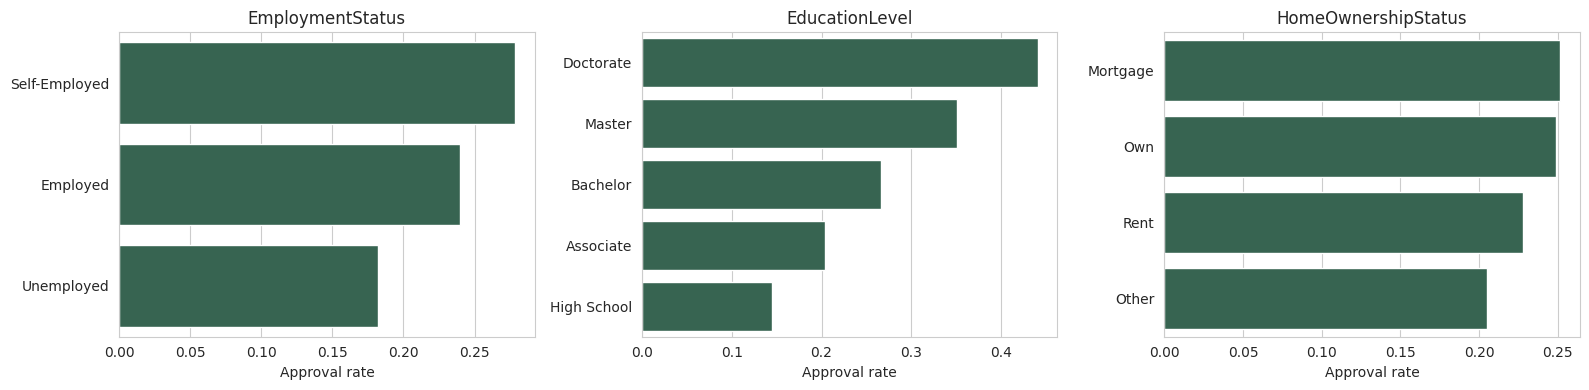

In [ ]:
categorical_preview = ["EmploymentStatus", "EducationLevel", "HomeOwnershipStatus"]

fig, axes = plt.subplots(1, len(categorical_preview), figsize=(16, 4))
for ax, col in zip(axes, categorical_preview):
    rates = df.groupby(col)["LoanApproved"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, color="#2F6B52", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Approval rate")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
correlation_preview = ["Age", "AnnualIncome", "CreditScore", "LoanAmount",
                        "TotalDebtToIncomeRatio", "TotalAssets", "NetWorth", "LoanApproved"]

corr = df[correlation_preview].corr()
corr["LoanApproved"].sort_values(ascending=False)

,LoanApproved
LoanApproved,1.000000
AnnualIncome,0.597900
NetWorth,0.187892
TotalAssets,0.184011
CreditScore,0.142000
Age,0.141029
LoanAmount,-0.239496
TotalDebtToIncomeRatio,-0.410399


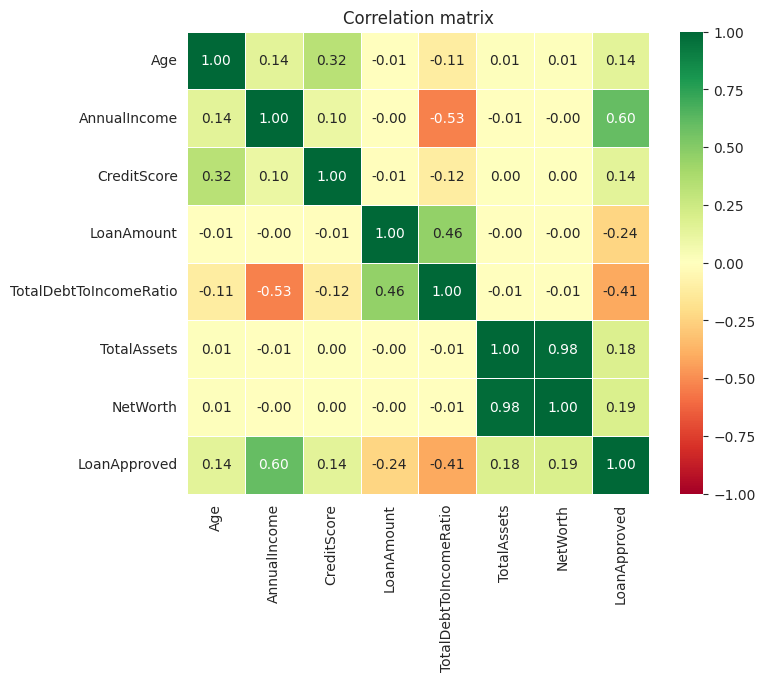

In [ ]:
correlation_preview = ["Age", "AnnualIncome", "CreditScore", "LoanAmount",
                        "TotalDebtToIncomeRatio", "TotalAssets", "NetWorth", "LoanApproved"]

corr = df[correlation_preview].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

In [ ]:
df = df.drop(columns=["TotalAssets"])

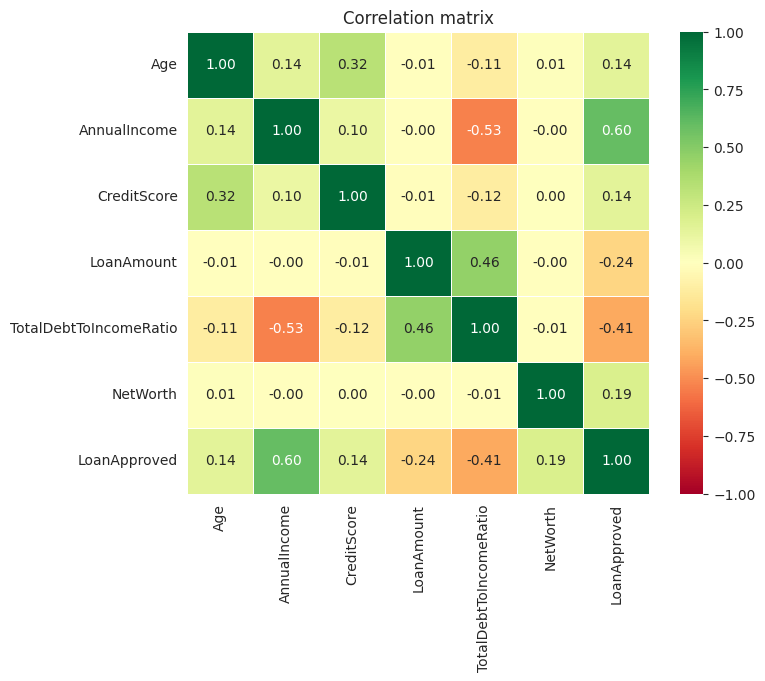

In [ ]:
correlation_preview = ["Age", "AnnualIncome", "CreditScore", "LoanAmount",
                        "TotalDebtToIncomeRatio", "NetWorth", "LoanApproved"]

corr = df[correlation_preview].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

## 1.3 Define the leakage-safe feature set

Not every column in this dataset is fair game for a model to learn from. Before any imputation, scaling, or feature selection happens, we draw an explicit line between columns that reflect what a lender genuinely knows *at the moment of application*, and columns that don't belong in that set, either because they reveal the decision itself, aren't a real field to begin with, or duplicate information another column already carries.

This section defines that line once, as a small set of reusable lists, so every model built later in the notebook draws from the same leakage-safe feature set rather than each step re-deciding it independently.

In [ ]:
target_col = "LoanApproved"
leak_cols = ["RiskScore", "InterestRate", "BaseInterestRate", "MonthlyLoanPayment", "ApplicationDate"]
cat_cols = ["EmploymentStatus", "EducationLevel", "MaritalStatus", "HomeOwnershipStatus", "LoanPurpose"]
redundant_cols = ["TotalAssets"]

num_cols = [c for c in df.columns if c not in leak_cols + cat_cols + redundant_cols + [target_col]]
candidate_features = num_cols + cat_cols

print(f"{len(num_cols)} numeric candidates, {len(cat_cols)} categorical candidates")
print("Target balance:\n", df[target_col].value_counts(normalize=True))

24 numeric candidates, 5 categorical candidates
Target balance:
 LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


## 1.4 Simulate realistic missingness (MAR)

`Loan.csv` arrived with no missing values, already cleaned before upload so there's nothing here yet for an imputation method to genuinely reconstruct. This section fixes that deliberately: we mask a set of numeric columns ourselves, using the *amputation* approach, so we know the true values underneath and can later check how well imputation recovers them.

The masking isn't uniform. Most columns get a flat 15% missing at random (MCAR), but `AnnualIncome` and `MonthlyIncome` are masked more heavily for self-employed applicants specifically, this makes the missingness **Missing At Random (MAR)** rather than MCAR, mirroring how income under-reporting actually clusters in real applications rather than striking every applicant with equal, uniform probability.


In [ ]:
impute_cols = ['AnnualIncome', 'CreditScore', 'LoanAmount', 'MonthlyDebtPayments',
               'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'DebtToIncomeRatio',
               'SavingsAccountBalance', 'TotalLiabilities', 'MonthlyIncome',
               'NetWorth', 'LengthOfCreditHistory']

X_true = df[impute_cols].values.astype(np.float32)
n, d = X_true.shape
rng = np.random.default_rng(42)

miss_mask = (rng.random((n, d)) < 0.15).astype(np.float32)  # baseline 15% MCAR
self_employed = (df["EmploymentStatus"] == "Self-Employed").values
for col in ["AnnualIncome", "MonthlyIncome"]:
    j = impute_cols.index(col)
    extra_missing = (rng.random(n) < 0.25) & self_employed
    miss_mask[extra_missing, j] = 1.0

X_obs = X_true.copy()
X_obs[miss_mask == 1] = np.nan
M = 1 - miss_mask  # 1 = observed, 0 = missing

print(f"{d} columns selected for imputation")
print(f"Overall missingness: {miss_mask.mean():.1%}")
print(f"Missingness in AnnualIncome for self-employed: {miss_mask[self_employed, impute_cols.index('AnnualIncome')].mean():.1%}")
print(f"Missingness in AnnualIncome for everyone else: {miss_mask[~self_employed, impute_cols.index('AnnualIncome')].mean():.1%}")

12 columns selected for imputation
Overall missingness: 15.3%
Missingness in AnnualIncome for self-employed: 37.8%
Missingness in AnnualIncome for everyone else: 14.7%


## 1.3 GAIN: Generative Adversarial Imputation Nets

**Why not just median-fill?** Median imputation always predicts the same single value for every missing cell in a column it collapses the natural variance of that column to zero among the imputed rows. GAIN instead trains a **generator** to fill gaps plausibly and a **discriminator** to guess *which* cells were originally observed vs. generated (given a partial "hint"). As the generator gets better at fooling the discriminator, its fills become genuinely distribution-consistent rather than a single repeated number.

This is the original Yoon et al. (2018) GAIN architecture, implemented directly in PyTorch.

In [ ]:
class Generator(nn.Module):
    def __init__(self, dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim), nn.Sigmoid()
        )
    def forward(self, x, m):
        return self.net(torch.cat([x, m], dim=1))

class Discriminator(nn.Module):
    def __init__(self, dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim), nn.Sigmoid()
        )
    def forward(self, x, h):
        return self.net(torch.cat([x, h], dim=1))

In [ ]:
# GAIN works with inputs scaled to [0, 1] (its generator ends in a Sigmoid)
mn, mx = np.nanmin(X_obs, axis=0), np.nanmax(X_obs, axis=0)
X_norm = (np.nan_to_num(X_obs, nan=0.0) - mn) / (mx - mn + 1e-8)
X_norm_t = torch.tensor(X_norm, dtype=torch.float32)
M_t = torch.tensor(M, dtype=torch.float32)

G, D = Generator(d), Discriminator(d)
opt_g = torch.optim.Adam(G.parameters(), lr=1e-3)
opt_d = torch.optim.Adam(D.parameters(), lr=1e-3)
bce = nn.BCELoss()

HINT_RATE = 0.9   # fraction of the mask revealed to the discriminator as a "hint"
ALPHA = 10.0       # weight on the reconstruction loss for observed values
BATCH = 128
N_ITERS = 1500

t0 = time.time()
for it in range(N_ITERS):
    idx = torch.randperm(n)[:BATCH]
    Xb, Mb = X_norm_t[idx], M_t[idx]
    Zb = torch.rand_like(Xb) * 0.01                       # small random noise fills the gaps pre-generation
    Xb_tilde = Mb * Xb + (1 - Mb) * Zb

    hint_bits = (torch.rand_like(Mb) < HINT_RATE).float()
    Hb = hint_bits * Mb + 0.5 * (1 - hint_bits)            # 0.5 = "no hint" for that cell

    # --- Discriminator step: guess which cells were truly observed ---
    G_sample = G(Xb_tilde, Mb)
    Xb_hat = Mb * Xb + (1 - Mb) * G_sample
    D_prob = D(Xb_hat.detach(), Hb)
    D_loss = bce(D_prob, Mb)
    opt_d.zero_grad(); D_loss.backward(); opt_d.step()

    # --- Generator step: fool the discriminator + reconstruct observed values ---
    G_sample = G(Xb_tilde, Mb)
    Xb_hat = Mb * Xb + (1 - Mb) * G_sample
    D_prob = D(Xb_hat, Hb)
    G_loss_adv = bce(D_prob * (1 - Mb) + Mb, torch.ones_like(Mb))
    G_loss_mse = torch.sum((Mb * Xb - Mb * G_sample) ** 2) / (torch.sum(Mb) + 1e-8)
    G_loss = G_loss_adv + ALPHA * G_loss_mse
    opt_g.zero_grad(); G_loss.backward(); opt_g.step()

    if it % 300 == 0:
        print(f"iter {it:4d} | D_loss {D_loss.item():.3f} | G_loss {G_loss.item():.3f}")

print(f"\nGAIN trained in {time.time()-t0:.1f}s")

iter    0 | D_loss 0.685 | G_loss 1.451
iter  300 | D_loss 0.110 | G_loss 0.286
iter  600 | D_loss 0.066 | G_loss 0.448
iter  900 | D_loss 0.048 | G_loss 0.592
iter 1200 | D_loss 0.054 | G_loss 0.639

GAIN trained in 18.8s


In [ ]:
with torch.no_grad():
    G_sample = G(X_norm_t, M_t)
    X_imp_norm = M_t * X_norm_t + (1 - M_t) * G_sample
X_gain = X_imp_norm.numpy() * (mx - mn + 1e-8) + mn

# Median-imputation baseline, kept for the variance-preservation check further below
X_median = X_obs.copy()
for j in range(d):
    med = np.nanmedian(X_obs[:, j])
    X_median[np.isnan(X_median[:, j]), j] = med

In [ ]:
rows = []
for j, col in enumerate(impute_cols):
    m = miss_mask[:, j] == 1
    col_range = X_true[:, j].max() - X_true[:, j].min()
    mae = np.abs(X_gain[m, j] - X_true[m, j]).mean()
    mae_pct_range = mae / col_range
    true_var = np.var(X_true[m, j])
    gain_var = np.var(X_gain[m, j])
    var_retained = gain_var / true_var if true_var > 0 else np.nan
    rows.append([col, mae, mae_pct_range, var_retained])

gain_performance = pd.DataFrame(rows, columns=["column", "mae", "mae_pct_of_range", "variance_retained"])
gain_performance["mae_pct_of_range"] = (gain_performance["mae_pct_of_range"] * 100).round(1)
gain_performance["variance_retained"] = (gain_performance["variance_retained"] * 100).round(1)
gain_performance

,column,mae,mae_pct_of_range,variance_retained
0,AnnualIncome,20126.009766,4.300000,28.799999
1,CreditScore,200.417084,54.299999,1.900000
2,LoanAmount,29724.691406,16.400000,72.599998
3,MonthlyDebtPayments,186.226822,6.500000,3.600000
4,CreditCardUtilizationRate,0.130175,14.200000,1.400000
5,NumberOfOpenCreditLines,1.699718,13.100000,1.000000
6,DebtToIncomeRatio,0.146765,16.299999,1.000000
7,SavingsAccountBalance,3718.847900,1.900000,2.600000
8,TotalLiabilities,26550.244141,1.900000,4.200000
9,MonthlyIncome,1885.249146,7.900000,9.400000


###1.3.1 Does GAIN preserve variance, where median can't?

Median imputation *always* predicts the same number by construction its variance among imputed cells is exactly zero. That's the "distorts variance" problem in the brief. Let's check whether GAIN actually does better.

Variance among masked AnnualIncome cells:
  True data:        1,645,864,064
  GAIN imputation:  474,022,080  (29% of true variance retained)
  Median imputation:0  (0% — always the same number)


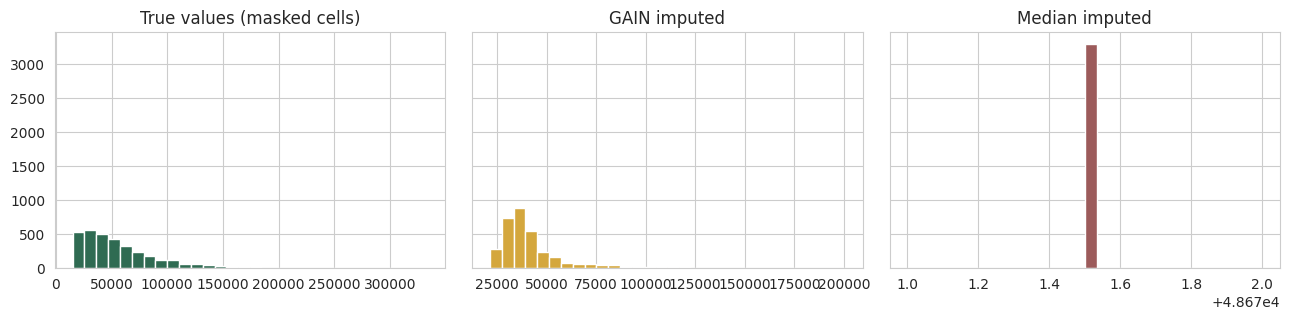

In [ ]:
col = "AnnualIncome"
j = impute_cols.index(col)
masked = miss_mask[:, j] == 1

true_var = np.var(X_true[masked, j])
gain_var = np.var(X_gain[masked, j])
median_var = np.var(X_median[masked, j])

print(f"Variance among masked {col} cells:")
print(f"  True data:        {true_var:,.0f}")
print(f"  GAIN imputation:  {gain_var:,.0f}  ({gain_var/true_var:.0%} of true variance retained)")
print(f"  Median imputation:{median_var:,.0f}  (0% — always the same number)")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=True)
axes[0].hist(X_true[masked, j], bins=30, color="#2F6B52"); axes[0].set_title("True values (masked cells)")
axes[1].hist(X_gain[masked, j], bins=30, color="#D4A73D"); axes[1].set_title("GAIN imputed")
axes[2].hist(X_median[masked, j], bins=30, color="#9C5B5B"); axes[2].set_title("Median imputed")
plt.tight_layout(); plt.show()

In [ ]:
# Write the GAIN-imputed values back into the full dataframe
df_imputed = df.copy()
df_imputed[impute_cols] = X_gain
print("Missing values remaining:", df_imputed[impute_cols].isna().sum().sum())

Missing values remaining: 0


## 1.6 Scaling: RobustScaler (IQR) → Yeo-Johnson power transform

Financial fields like income and net worth are heavy-tailed, a handful of very high earners can dominate a model's gradient updates if left unscaled. This section applies a two-stage transform to every numeric feature to correct for that, before anything is trained on them:

1. **RobustScaler** centers and scales using the **median and interquartile range** instead of mean/standard deviation, far less sensitive to the extreme high-value outliers that plague income and net-worth fields.
2. **Yeo-Johnson power transform** then reshapes the distribution toward Gaussian unlike a log transform, Yeo-Johnson handles zero and negative values too (useful here, since `NetWorth` can be negative).


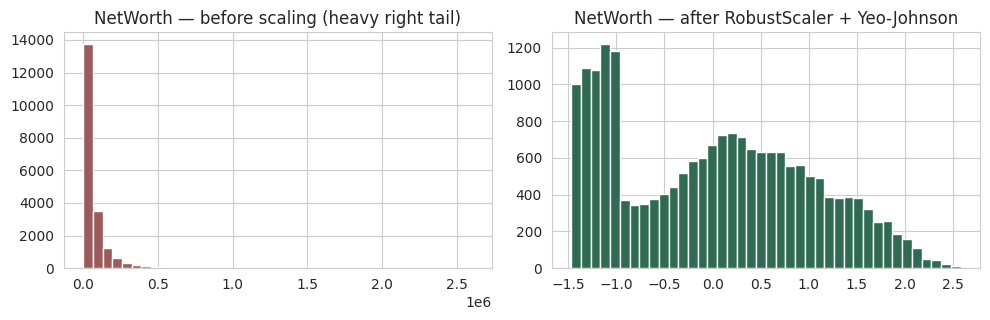

In [ ]:
from sklearn.preprocessing import RobustScaler, PowerTransformer, OrdinalEncoder

before = df_imputed["NetWorth"].copy()

robust = RobustScaler()
X_robust = robust.fit_transform(df_imputed[num_cols])

yeo = PowerTransformer(method="yeo-johnson")
X_scaled_num = yeo.fit_transform(X_robust)

df_scaled = df_imputed.copy()
df_scaled[num_cols] = X_scaled_num

fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
axes[0].hist(before, bins=40, color="#9C5B5B"); axes[0].set_title("NetWorth — before scaling (heavy right tail)")
axes[1].hist(df_scaled["NetWorth"], bins=40, color="#2F6B52"); axes[1].set_title("NetWorth — after RobustScaler + Yeo-Johnson")
plt.tight_layout(); plt.show()

In [ ]:
# Encode categoricals
encoder = OrdinalEncoder()
df_scaled[cat_cols] = encoder.fit_transform(df_imputed[cat_cols])

X_all = df_scaled[candidate_features]
y_all = df_scaled[target_col]
print(X_all.shape)
X_all.head()

(20000, 29)


,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,TotalDebtToIncomeRatio,EmploymentStatus,EducationLevel,MaritalStatus,HomeOwnershipStatus,LoanPurpose
0,0.480635,-0.273853,1.003393,0.461074,-1.171803,-0.124277,0.535489,-1.686294,0.114460,-1.237505,...,-0.295061,-0.760024,2.328840,1.191199,-0.776763,0.0,4.0,1.0,2.0,3.0
1,-0.115679,-0.285858,1.260519,-0.152915,0.080712,-0.124277,-0.203349,0.557062,-1.530505,-0.525643,...,-0.307416,1.305854,-0.902592,0.144038,0.364811,0.0,0.0,2.0,0.0,1.0
2,0.645814,-0.235428,0.103282,0.785579,-0.665112,-0.704457,0.535489,-0.017510,-1.068865,-0.379449,...,-0.255522,0.525907,0.517027,-1.249676,0.607843,0.0,1.0,1.0,3.0,2.0
3,1.524545,0.279158,-0.246810,1.394222,0.774302,1.547667,-0.203349,1.386089,-0.004714,-0.379449,...,0.726250,0.806051,0.083924,0.970574,0.038968,0.0,3.0,2.0,0.0,3.0
4,-0.203477,1.331820,-1.672853,0.029664,-1.685414,-0.704457,-0.203349,-0.825215,0.357223,-2.299633,...,1.360582,1.390661,0.083924,-0.287475,-1.750630,0.0,0.0,1.0,0.0,1.0


## 1.7 Feature Selection: Boruta-SHAP  

This section runs a statistically grounded test to separate genuinely predictive features from ones that only look useful.

**How it works:** for every real feature, create a **shadow feature** the same column, randomly shuffled, so it has *no* real relationship to the target by construction. Train a model on real and shadow features together, and rank importance with **SHAP** rather than a model's native feature importances (SHAP importance better reflects each feature's actual contribution to individual predictions, rather than how often a tree happened to split on it). A real feature only "wins" a round if its importance beats the *best* shadow feature that round the shadow features set a genuine, data-driven noise floor, rather than an arbitrary cutoff we'd have to choose ourselves. Repeat over many rounds; keep the features that win consistently.

*(We implement this from scratch rather than using the `BorutaShap` package since it's unmaintained and breaks on current NumPy/SciPy. The version below is a direct, transparent implementation of the same idea.)*

In [ ]:
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.25, random_state=42, stratify=y_all)

N_ITER = 15
rng = np.random.default_rng(0)
hits = pd.Series(0, index=Xtr.columns)

t0 = time.time()
for i in range(N_ITER):
    shadow = Xtr.apply(lambda c: rng.permutation(c.values))
    shadow.columns = [f"shadow_{c}" for c in shadow.columns]
    combo = pd.concat([Xtr.reset_index(drop=True), shadow.reset_index(drop=True)], axis=1)

    model = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=i, eval_metric="logloss")
    model.fit(combo, ytr.reset_index(drop=True))

    explainer = shap.TreeExplainer(model)
    sv = explainer(combo.iloc[:500])              # a sample is enough to rank importance
    imp = pd.Series(np.abs(sv.values).mean(axis=0), index=combo.columns)

    max_shadow = imp[[c for c in imp.index if c.startswith("shadow_")]].max()
    real_imp = imp[Xtr.columns]
    hits += (real_imp > max_shadow).astype(int)

print(f"Boruta-SHAP ({N_ITER} rounds) finished in {time.time()-t0:.1f}s")

boruta_result = pd.DataFrame({"hits": hits, "hit_rate": hits / N_ITER}).sort_values("hit_rate", ascending=False)
boruta_result

Boruta-SHAP (15 rounds) finished in 15.7s


,hits,hit_rate
Age,15,1.000000
AnnualIncome,15,1.000000
CreditScore,15,1.000000
Experience,15,1.000000
LoanDuration,15,1.000000
BankruptcyHistory,15,1.000000
MonthlyDebtPayments,15,1.000000
EmploymentStatus,15,1.000000
EducationLevel,15,1.000000
MonthlyIncome,15,1.000000


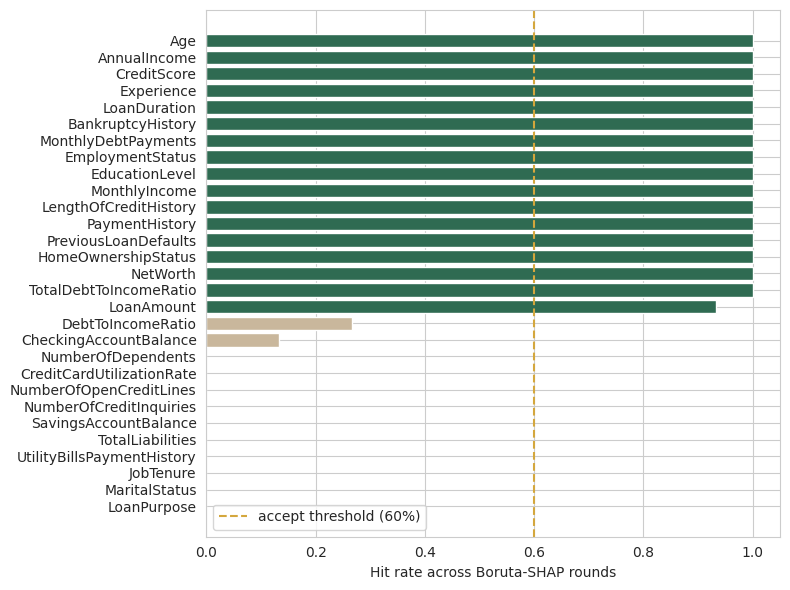


17 features accepted:
 ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanDuration', 'BankruptcyHistory', 'MonthlyDebtPayments', 'EmploymentStatus', 'EducationLevel', 'MonthlyIncome', 'LengthOfCreditHistory', 'PaymentHistory', 'PreviousLoanDefaults', 'HomeOwnershipStatus', 'NetWorth', 'TotalDebtToIncomeRatio', 'LoanAmount']


In [ ]:
HIT_THRESHOLD = 0.6
accepted_features = boruta_result[boruta_result["hit_rate"] >= HIT_THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2F6B52" if h >= HIT_THRESHOLD else "#C9B79C" for h in boruta_result["hit_rate"]]
ax.barh(boruta_result.index[::-1], boruta_result["hit_rate"][::-1], color=colors[::-1])
ax.axvline(HIT_THRESHOLD, color="#D4A73D", linestyle="--", label=f"accept threshold ({HIT_THRESHOLD:.0%})")
ax.set_xlabel("Hit rate across Boruta-SHAP rounds")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\n{len(accepted_features)} features accepted:\n", accepted_features)

## 1.8 Prediction: TabNet vs. Monotonic XGBoost

This section trains two very different models on the same Boruta-SHAP-selected features, so we can compare a constrained, auditable model against a more flexible deep model on equal footing.

**Monotonic XGBoost:** tree ensembles are the proven default for tabular data, it builds many small decision trees one after another, where each new tree corrects the errors of the ones before it. The final prediction is the sum of all the trees' corrections. The monotonic constraint restricts which splits a tree is allowed to make, so the guarantee holds by construction.

we force certain features to have a strictly consistent direction of effect for example, higher `NetWorth`/`AnnualIncome` can only ever *increase* predicted approval probability, higher `TotalDebtToIncomeRatio`/`BankruptcyHistory`/`PreviousLoanDefaults` can only ever *decrease* it. This isn't just a nice-to-have: a model that could (even rarely) predict that *more* debt improves your odds would be very hard to defend to a regulator or an applicant, no matter how good its overall accuracy looks.

**TabNet:** a deep learning architecture built specifically for tabular data, using sequential attention to pick a different subset of features to focus on at each decision step. A learned, soft alternative to hand-built feature selection. We benchmark it against the constrained XGBoost model on the same train/test split.

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix, brier_score_loss, log_loss)

In [ ]:
Xtr_sel, Xte_sel = Xtr[accepted_features], Xte[accepted_features]

# Direction of effect on approval probability: +1 = higher value should increase approval odds,
# -1 = higher value should decrease approval odds, 0 = no constraint enforced.
# Defined for every candidate column so this is robust even if Boruta's accepted set shifts slightly.
monotone_direction = {
    "Age": 0, "AnnualIncome": 1, "CreditScore": 1, "Experience": 0,
    "LoanAmount": -1, "LoanDuration": 0, "NumberOfDependents": 0,
    "MonthlyDebtPayments": -1, "CreditCardUtilizationRate": -1,
    "NumberOfOpenCreditLines": 0, "NumberOfCreditInquiries": -1,
    "DebtToIncomeRatio": -1, "BankruptcyHistory": -1, "PreviousLoanDefaults": -1,
    "PaymentHistory": 1, "LengthOfCreditHistory": 1, "SavingsAccountBalance": 1,
    "CheckingAccountBalance": 1, "TotalAssets": 1, "TotalLiabilities": -1,
    "MonthlyIncome": 1, "UtilityBillsPaymentHistory": 1, "JobTenure": 1,
    "NetWorth": 1, "TotalDebtToIncomeRatio": -1,
    "EmploymentStatus": 0, "EducationLevel": 0, "MaritalStatus": 0,
    "HomeOwnershipStatus": 0, "LoanPurpose": 0
}
mono_tuple = tuple(monotone_direction[c] for c in accepted_features)
print("Monotonic constraints applied:\n", dict(zip(accepted_features, mono_tuple)))

Monotonic constraints applied:
 {'Age': 0, 'AnnualIncome': 1, 'CreditScore': 1, 'Experience': 0, 'LoanDuration': 0, 'BankruptcyHistory': -1, 'MonthlyDebtPayments': -1, 'EmploymentStatus': 0, 'EducationLevel': 0, 'MonthlyIncome': 1, 'LengthOfCreditHistory': 1, 'PaymentHistory': 1, 'PreviousLoanDefaults': -1, 'HomeOwnershipStatus': 0, 'NetWorth': 1, 'TotalDebtToIncomeRatio': -1, 'LoanAmount': -1}


In [ ]:
mono_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    monotone_constraints=mono_tuple, eval_metric="auc", random_state=42
)
mono_clf.fit(
    Xtr_sel, ytr,
    eval_set=[(Xtr_sel, ytr), (Xte_sel, yte)],
    verbose=False
)
auc_xgb = roc_auc_score(yte, mono_clf.predict_proba(Xte_sel)[:, 1])
print(f"Monotonic XGBoost AUC: {auc_xgb:.4f}")

Monotonic XGBoost AUC: 0.9669


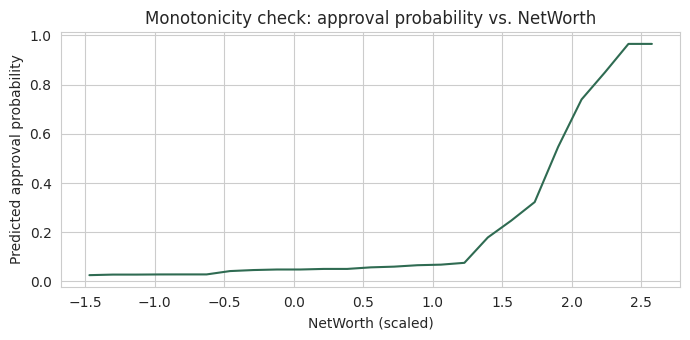

Strictly non-decreasing across the sweep? True


In [ ]:
# Sanity-check the constraint actually holds: sweep NetWorth for one applicant, prediction must never decrease
sample = Xte_sel.iloc[[0]].copy()
sweep_vals = np.linspace(Xte_sel["NetWorth"].min(), Xte_sel["NetWorth"].max(), 25)
sweep_preds = []
for v in sweep_vals:
    s = sample.copy(); s["NetWorth"] = v
    sweep_preds.append(mono_clf.predict_proba(s)[:, 1][0])

plt.figure(figsize=(7, 3.5))
plt.plot(sweep_vals, sweep_preds, color="#2F6B52")
plt.xlabel("NetWorth (scaled)"); plt.ylabel("Predicted approval probability")
plt.title("Monotonicity check: approval probability vs. NetWorth")
plt.tight_layout(); plt.show()

print("Strictly non-decreasing across the sweep?", np.all(np.diff(sweep_preds) >= -1e-9))

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(n_d=16, n_a=16, n_steps=3, gamma=1.3, seed=42, verbose=0, device_name="cpu")

In [ ]:
Xtr_arr = Xtr_sel.values.astype(np.float32)
Xte_arr = Xte_sel.values.astype(np.float32)
ytr_arr = ytr.values
yte_arr = yte.values

Xtr2, Xval, ytr2, yval = train_test_split(
    Xtr_arr, ytr_arr, test_size=0.15, random_state=42, stratify=ytr_arr
)

In [ ]:
tabnet.fit(
    Xtr2, ytr2,
    eval_set=[(Xtr2, ytr2), (Xval, yval)],
    eval_name=["train", "valid"],
    eval_metric=["auc"],
    max_epochs=40, patience=8, batch_size=512, virtual_batch_size=128
)


Early stopping occurred at epoch 31 with best_epoch = 23 and best_valid_auc = 0.97472


/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
tabnet_proba = tabnet.predict_proba(Xte_arr)[:, 1]
auc_tabnet = roc_auc_score(yte_arr, tabnet_proba)
print(f"TabNet AUC on the TEST set: {auc_tabnet:.4f}")
print(f"Monotonic XGBoost AUC on the TEST set: {auc_xgb:.4f}")

TabNet AUC on the TEST set: 0.9639
Monotonic XGBoost AUC on the TEST set: 0.9669


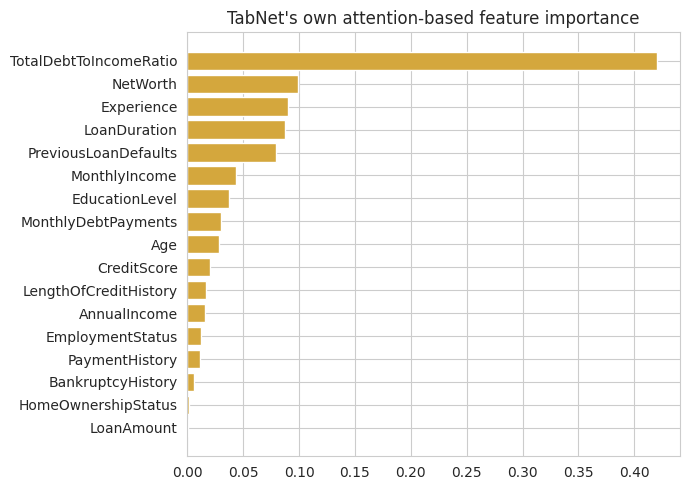

In [ ]:
importances = pd.Series(tabnet.feature_importances_, index=accepted_features).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
plt.barh(importances.index[::-1], importances.values[::-1], color="#D4A73D")
plt.title("TabNet's own attention-based feature importance")
plt.tight_layout(); plt.show()

In [ ]:
xgb_proba = mono_clf.predict_proba(Xte_sel)[:, 1]
tabnet_proba = tabnet.predict_proba(Xte_arr)[:, 1]

ensemble_proba = (xgb_proba + tabnet_proba) / 2
auc_ensemble = roc_auc_score(yte, ensemble_proba)

print(f"XGBoost AUC:   {auc_xgb:.4f}")
print(f"TabNet AUC:    {auc_tabnet:.4f}")
print(f"Ensemble AUC:  {auc_ensemble:.4f}")

XGBoost AUC:   0.9669
TabNet AUC:    0.9639
Ensemble AUC:  0.9683


In [ ]:
def compute_metrics(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    metrics = {
        "AUC-ROC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "Brier score": brier_score_loss(y_true, proba),
        "Log loss": log_loss(y_true, proba),
    }
    return metrics, cm

models_to_compare = {
    "Monotonic XGBoost": (yte, xgb_proba),
    "TabNet": (yte_arr, tabnet_proba),
}

all_metrics, all_cms = {}, {}
for name, (y_true, proba) in models_to_compare.items():
    metrics, cm = compute_metrics(y_true, proba)
    all_metrics[name] = metrics
    all_cms[name] = cm

# one combined metrics table
results_table = pd.DataFrame(all_metrics).round(4)
results_table

,Monotonic XGBoost,TabNet
AUC-ROC,0.9669,0.9639
PR-AUC,0.9111,0.9094
Precision,0.8411,0.8630
Recall,0.8017,0.7699
F1,0.8209,0.8138
Brier score,0.0601,0.0617
Log loss,0.1954,0.2041


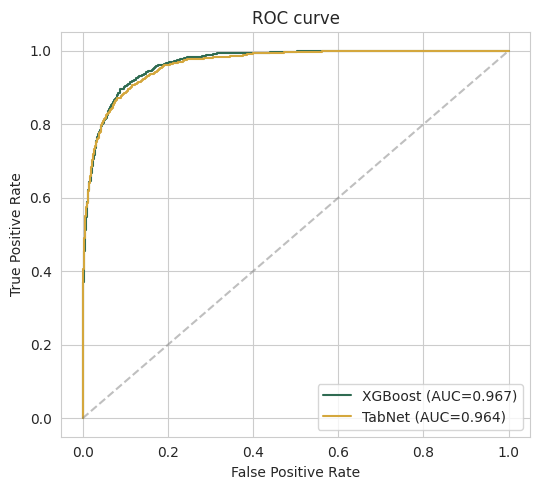

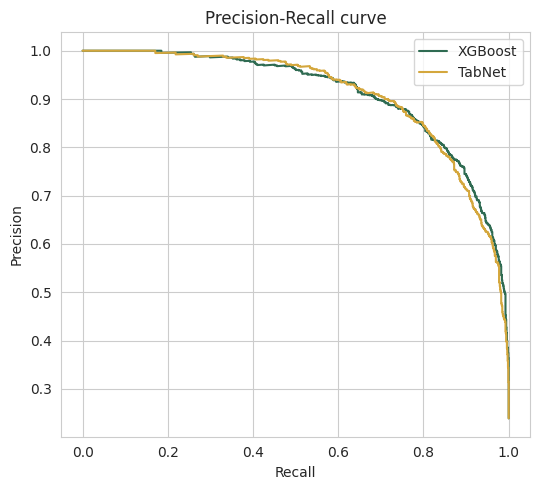

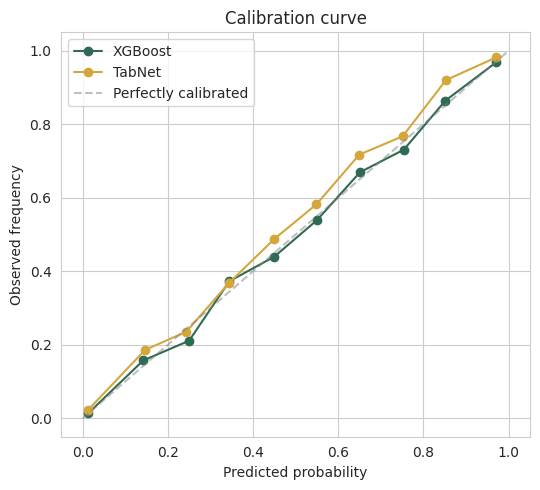

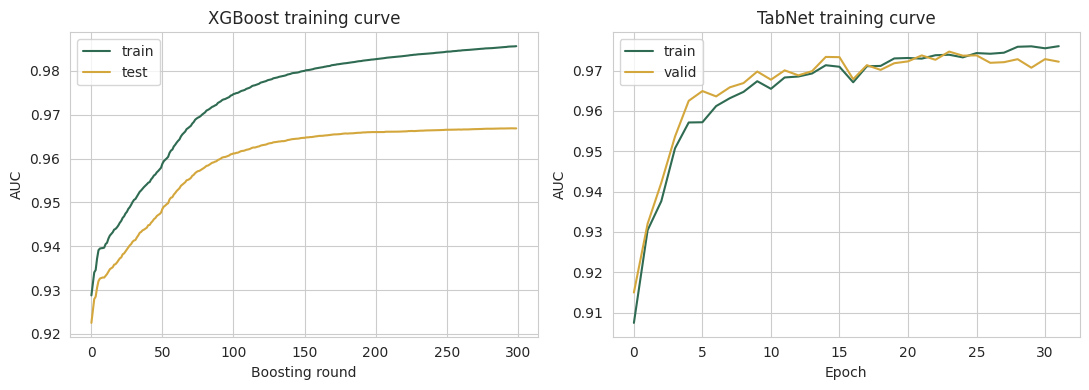

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.calibration import calibration_curve

# 1. ROC curve
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, y_true, proba, color in [("XGBoost", yte, xgb_proba, "#2F6B52"), ("TabNet", yte_arr, tabnet_proba, "#D4A73D")]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})", color=color)
ax.plot([0,1],[0,1], "--", color="gray", alpha=0.5)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve"); ax.legend()
plt.tight_layout(); plt.show()

# 2. Precision-Recall curve
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, y_true, proba, color in [("XGBoost", yte, xgb_proba, "#2F6B52"), ("TabNet", yte_arr, tabnet_proba, "#D4A73D")]:
    prec, rec, _ = precision_recall_curve(y_true, proba)
    ax.plot(rec, prec, label=name, color=color)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve"); ax.legend()
plt.tight_layout(); plt.show()

# 3. Calibration curve
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, y_true, proba, color in [("XGBoost", yte, xgb_proba, "#2F6B52"), ("TabNet", yte_arr, tabnet_proba, "#D4A73D")]:
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, "o-", label=name, color=color)
ax.plot([0,1],[0,1], "--", color="gray", alpha=0.5, label="Perfectly calibrated")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Calibration curve"); ax.legend()
plt.tight_layout(); plt.show()

# 4. Training curves (needs eval_set passed to .fit() for both models)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xgb_history = mono_clf.evals_result()
axes[0].plot(xgb_history["validation_0"]["auc"], label="train", color="#2F6B52")
axes[0].plot(xgb_history["validation_1"]["auc"], label="test", color="#D4A73D")
axes[0].set_title("XGBoost training curve"); axes[0].set_xlabel("Boosting round"); axes[0].set_ylabel("AUC"); axes[0].legend()

tabnet_hist = tabnet.history
axes[1].plot(tabnet_hist["train_auc"], label="train", color="#2F6B52")
axes[1].plot(tabnet_hist["valid_auc"], label="valid", color="#D4A73D")
axes[1].set_title("TabNet training curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC"); axes[1].legend()
plt.tight_layout(); plt.show()

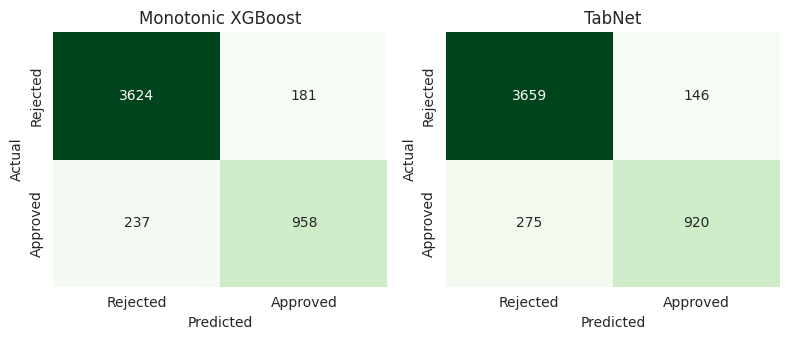

In [ ]:
# one combined figure, confusion matrices side by side
fig, axes = plt.subplots(1, len(all_cms), figsize=(4 * len(all_cms), 3.5))
for ax, (name, cm) in zip(axes, all_cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 1.9 Explainability: SHAP + DiCE

A resilient credit decision isn't just accurate, it has to be defensible. This section adds two complementary explanation methods to the final model selected in 1.8, so a decision can be interrogated from both directions; an auditor and an applicant actually care about: *why* did the model decide this, and *what* would need to change for a different outcome.



### 1.9.1 SHapley Additive exPlanations (SHAP)
SHAP breaks down each individual prediction into the contribution of every feature, then lets us aggregate those contributions across all test applicants to see which features drive the model's decisions overall not just which features a tree happened to split on most, but how much each one actually moved predictions.

/tmp/ipykernel_34467/2923425941.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(xgb_shap, Xte_sel, show=False)


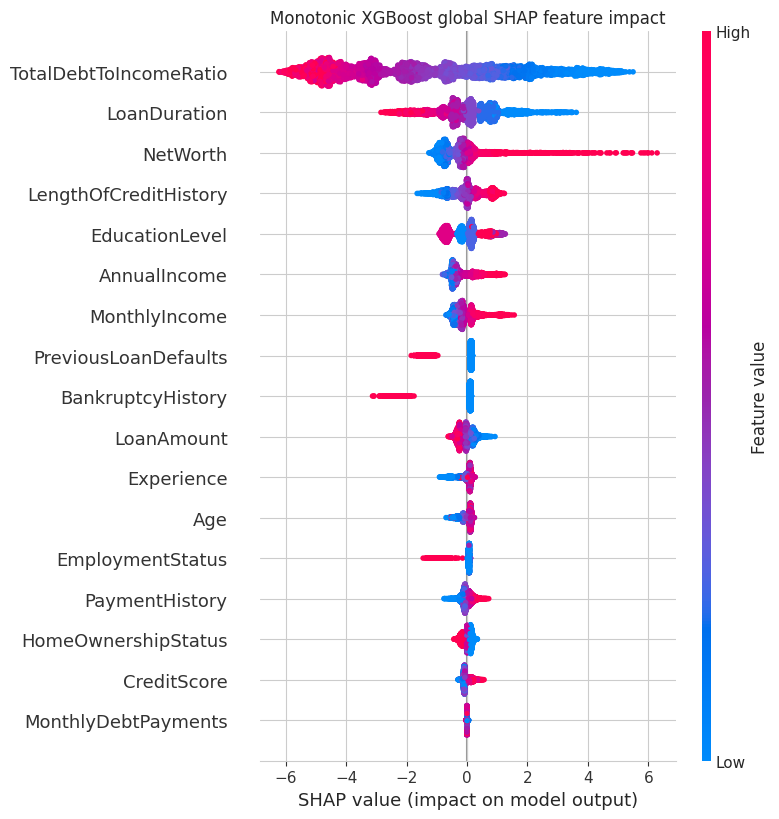

In [ ]:
# XGBoost: exact, fast TreeExplainer
xgb_explainer = shap.TreeExplainer(mono_clf)
xgb_shap = xgb_explainer(Xte_sel)
shap.summary_plot(xgb_shap, Xte_sel, show=False)
plt.title("Monotonic XGBoost global SHAP feature impact")
plt.tight_layout(); plt.show()

PermutationExplainer explainer: 31it [00:28,  1.10s/it]
/tmp/ipykernel_34467/603613358.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(tabnet_shap, explain_sample, feature_names=accepted_features, show=False)


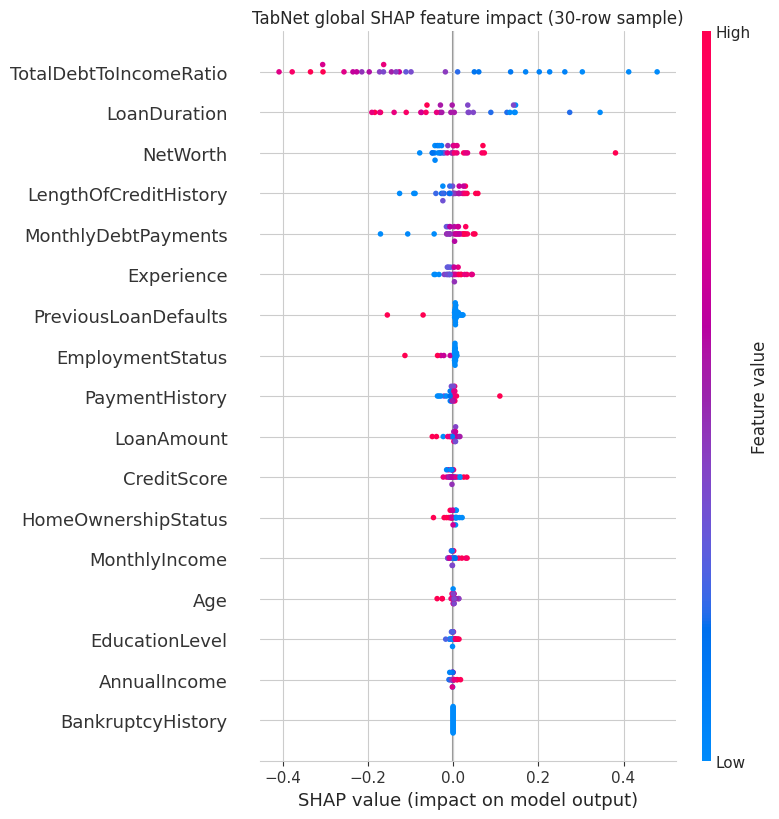

In [ ]:
# TabNet: not tree-based, so we use a model-agnostic Permutation explainer.
# Kept to a small sample -- this is meaningfully slower than TreeExplainer, which is
# exactly why tree ensembles remain attractive for auditability in production credit systems.
def tabnet_predict_fn(data):
    return tabnet.predict_proba(data.astype(np.float32))[:, 1]

background = Xte_arr[:50]
explain_sample = Xte_arr[:30]

tabnet_explainer = shap.Explainer(tabnet_predict_fn, background, feature_names=accepted_features)
tabnet_shap = tabnet_explainer(explain_sample)

shap.summary_plot(tabnet_shap, explain_sample, feature_names=accepted_features, show=False)
plt.title("TabNet global SHAP feature impact (30-row sample)")
plt.tight_layout(); plt.show()

###1.9.2 Diverse Counterfactual Explanations (DiCE)

SHAP tells you *why* the model made a decision. DiCE goes one step further and answers the question a rejected applicant actually asks: **"what would I need to change to get approved?"** We restrict the search to features an applicant can plausibly act on, nobody can change their `Age` or `EducationLevel` on demand, but income, assets, and requested loan amount are genuinely actionable.



In [ ]:
import dice_ml
from dice_ml import Dice

actionable_features = [f for f in ["AnnualIncome", "MonthlyIncome", "TotalAssets",
                                     "NetWorth", "LoanAmount", "TotalDebtToIncomeRatio",
                                     "SavingsAccountBalance", "CheckingAccountBalance"]
                        if f in accepted_features]

continuous_features = [f for f in accepted_features if f in num_cols]
df_for_dice = pd.concat([Xtr_sel, ytr], axis=1).rename(columns={target_col: "target"})

dice_data = dice_ml.Data(dataframe=df_for_dice, continuous_features=continuous_features, outcome_name="target")
dice_model = dice_ml.Model(model=mono_clf, backend="sklearn")
dice_exp = Dice(dice_data, dice_model, method="random")

# pick a genuinely rejected applicant from the test set
rejected_idx = yte[yte == 0].index[:1]
query_instance = Xte_sel.loc[rejected_idx]

print("Rejected applicant's predicted approval probability:",
      round(mono_clf.predict_proba(query_instance)[:, 1][0], 4))

counterfactuals = dice_exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite",
    features_to_vary=actionable_features
)
counterfactuals.visualize_as_dataframe(show_only_changes=True)

Rejected applicant's predicted approval probability: 0.0602


100%|██████████| 1/1 [00:00<00:00,  3.87it/s]

Query instance (original outcome : 0)


,Age,AnnualIncome,CreditScore,Experience,LoanDuration,BankruptcyHistory,MonthlyDebtPayments,EmploymentStatus,EducationLevel,MonthlyIncome,LengthOfCreditHistory,PaymentHistory,PreviousLoanDefaults,HomeOwnershipStatus,NetWorth,TotalDebtToIncomeRatio,LoanAmount,target
0,2.139392,1.061534,2.021553,2.23474,0.803004,-0.235154,-0.620546,0.0,0.0,1.078532,-0.397076,-0.163177,2.999167,2.0,0.736241,-0.66996,0.915785,0



Diverse Counterfactual set (new outcome: 1)


,Age,AnnualIncome,CreditScore,Experience,LoanDuration,BankruptcyHistory,MonthlyDebtPayments,EmploymentStatus,EducationLevel,MonthlyIncome,LengthOfCreditHistory,PaymentHistory,PreviousLoanDefaults,HomeOwnershipStatus,NetWorth,TotalDebtToIncomeRatio,LoanAmount,target
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-1.710275,-1.31917122,1.0
1,-,-,-,-,-,-,-,-,-,-0.43703,-,-,-,-,-,-1.55753,-,1.0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2.1678158,-,-,1.0


In [ ]:
rejected_idx = yte[yte == 0].index[:1]
query_instance = Xte_sel.loc[rejected_idx]
pred_proba = mono_clf.predict_proba(query_instance)[:, 1][0]
print(f"Applicant predicted approval probability: {pred_proba:.1%}  (rejected)")

# --- WHY: SHAP for this one applicant (reusing xgb_explainer from the earlier SHAP cell) ---
sv = xgb_explainer(query_instance)
print("\nSHAP contributions for this applicant:")
for feat, val in sorted(zip(accepted_features, sv.values[0]), key=lambda x: -abs(x[1])):
    print(f"  {feat:26s} {val:+.4f}")

# --- WHAT: DiCE counterfactuals for the same applicant ---
actionable_features = [f for f in ["AnnualIncome", "MonthlyIncome", "NetWorth", "LoanAmount",
                                     "TotalDebtToIncomeRatio", "SavingsAccountBalance",
                                     "CheckingAccountBalance"] if f in accepted_features]
continuous_features = [f for f in accepted_features if f in num_cols]
df_for_dice = pd.concat([Xtr_sel, ytr], axis=1).rename(columns={target_col: "target"})
dice_data = dice_ml.Data(dataframe=df_for_dice, continuous_features=continuous_features, outcome_name="target")
dice_model = dice_ml.Model(model=mono_clf, backend="sklearn")
dice_exp = Dice(dice_data, dice_model, method="random")

counterfactuals = dice_exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite", features_to_vary=actionable_features
)
counterfactuals.visualize_as_dataframe(show_only_changes=True)

Applicant predicted approval probability: 6.0%  (rejected)

SHAP contributions for this applicant:
  PreviousLoanDefaults       -1.2446
  LoanDuration               -0.6908
  AnnualIncome               +0.3205
  LoanAmount                 -0.2758
  LengthOfCreditHistory      -0.2398
  TotalDebtToIncomeRatio     +0.2114
  CreditScore                +0.2089
  EducationLevel             -0.2076
  MonthlyIncome              +0.1683
  BankruptcyHistory          +0.1060
  EmploymentStatus           +0.0728
  PaymentHistory             -0.0639
  NetWorth                   +0.0312
  HomeOwnershipStatus        +0.0279
  Age                        +0.0228
  Experience                 -0.0128
  MonthlyDebtPayments        +0.0002


100%|██████████| 1/1 [00:00<00:00,  3.80it/s]

Query instance (original outcome : 0)


,Age,AnnualIncome,CreditScore,Experience,LoanDuration,BankruptcyHistory,MonthlyDebtPayments,EmploymentStatus,EducationLevel,MonthlyIncome,LengthOfCreditHistory,PaymentHistory,PreviousLoanDefaults,HomeOwnershipStatus,NetWorth,TotalDebtToIncomeRatio,LoanAmount,target
0,2.139392,1.061534,2.021553,2.23474,0.803004,-0.235154,-0.620546,0.0,0.0,1.078532,-0.397076,-0.163177,2.999167,2.0,0.736241,-0.66996,0.915785,0



Diverse Counterfactual set (new outcome: 1)


,Age,AnnualIncome,CreditScore,Experience,LoanDuration,BankruptcyHistory,MonthlyDebtPayments,EmploymentStatus,EducationLevel,MonthlyIncome,LengthOfCreditHistory,PaymentHistory,PreviousLoanDefaults,HomeOwnershipStatus,NetWorth,TotalDebtToIncomeRatio,LoanAmount,target
0,-,2.649164,-,-,-,-,-,-,-,-,-,-,-,-,-,-1.948939,-,1.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-1.81008,-2.1496716,1.0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.6586805,-1.126082,-,1.0


In [ ]:
import textwrap

# LoanDuration is now included, alongside the existing actionable features
actionable_features = [f for f in ["AnnualIncome", "MonthlyIncome", "NetWorth", "LoanAmount", "LoanDuration",
                                     "TotalDebtToIncomeRatio", "SavingsAccountBalance",
                                     "CheckingAccountBalance"] if f in accepted_features]

pred_proba = mono_clf.predict_proba(query_instance)[:, 1][0]

counterfactuals = dice_exp.generate_counterfactuals(
    query_instance, total_CFs=20, desired_class="opposite", features_to_vary=actionable_features
)
cf_df = counterfactuals.cf_examples_list[0].final_cfs_df

def unscale(col, scaled_value):
    """Convert a RobustScaler + Yeo-Johnson scaled value back to real units."""
    if col not in num_cols:
        return scaled_value
    dummy = pd.DataFrame(np.zeros((1, len(num_cols))), columns=num_cols)
    dummy[col] = scaled_value
    unscaled = robust.inverse_transform(yeo.inverse_transform(dummy.values))
    return pd.Series(unscaled[0], index=num_cols)[col]

plain_names = {
    "LoanAmount": "the amount you requested", "LoanDuration": "the length of the loan",
    "PreviousLoanDefaults": "your history of past loan defaults", "NetWorth": "your overall net worth",
    "TotalDebtToIncomeRatio": "how much of your income already goes toward debt",
    "DebtToIncomeRatio": "your monthly debt-to-income ratio", "MonthlyIncome": "your monthly income",
    "AnnualIncome": "your annual income", "CreditScore": "your credit score",
    "SavingsAccountBalance": "your savings account balance", "CheckingAccountBalance": "your checking account balance",
    "LengthOfCreditHistory": "how long you've had credit", "BankruptcyHistory": "your bankruptcy history",
    "Age": "your age", "TotalLiabilities": "your total liabilities",
    "EducationLevel": "your education level", "EmploymentStatus": "your employment status",
}

# Look across ALL candidate counterfactuals (not just one) and, for each feature,
# keep the smallest realistic change that ever flipped the decision -- so every
# top reason gets its own targeted suggestion, not just whatever one combined
# counterfactual happened to touch.
per_feature_best = {}
for _, row in cf_df.iterrows():
    row_changes, is_coherent = {}, True
    for f in actionable_features:
        orig_val = query_instance[f].values[0]
        new_val = row[f]
        if isinstance(new_val, str) and new_val == "-":
            continue
        new_val = float(new_val)
        if abs(new_val - orig_val) > 1e-6:
            direction = monotone_direction.get(f, 0)
            moved_up = new_val > orig_val
            if (direction == 1 and not moved_up) or (direction == -1 and moved_up):
                is_coherent = False
                break
            row_changes[f] = new_val
    if not is_coherent:
        continue
    for f, new_val in row_changes.items():
        orig_val = query_instance[f].values[0]
        f_range = df_imputed[f].max() - df_imputed[f].min()
        magnitude = abs(new_val - orig_val) / f_range
        if f not in per_feature_best or magnitude < per_feature_best[f][0]:
            per_feature_best[f] = (magnitude, unscale(f, orig_val), unscale(f, new_val))

shap_pairs = sorted(zip(accepted_features, sv.values[0]), key=lambda x: x[1])
top_reasons = [(f, v) for f, v in shap_pairs[:3] if v < 0]

reason_labels = [plain_names.get(f, f) for f, v in top_reasons]
reasons_text = reason_labels[0]
if len(reason_labels) == 2:
    reasons_text += f" and {reason_labels[1]}"
elif len(reason_labels) >= 3:
    reasons_text += f", {reason_labels[1]}, and {reason_labels[2]}"

suggestion_lines = []
for f, _ in top_reasons:
    label = plain_names.get(f, f)
    if f in per_feature_best:
        _, old_v, new_v = per_feature_best[f]
        verb = "increasing" if new_v > old_v else "reducing"
        suggestion_lines.append(f"  - {verb.capitalize()} {label} to about {new_v:,.2f} (currently {old_v:,.2f})")
    else:
        suggestion_lines.append(f"  - {label.capitalize()} is not something you can directly change yourself")

paragraph_head = (
    f"Your predicted probability of approval is {pred_proba:.1%}. "
    f"Your loan application was not approved, mainly because of {reasons_text}."
)
paragraph_tail = (
    "Each suggestion below is a separate, realistic path based on applications similar to yours "
    "and assumes everything else about your application stays the same. "
    "This is not a guarantee please speak with a loan officer to discuss what might work best for your situation."
)

print(textwrap.fill(paragraph_head, width=80))
print("\nWhat could realistically change this decision:")
for line in suggestion_lines:
    print(textwrap.fill(line, width=80, subsequent_indent="    "))
print()
print(textwrap.fill(paragraph_tail, width=80))

100%|██████████| 1/1 [01:07<00:00, 67.59s/it]

Your predicted probability of approval is 6.0%. Your loan application was not
approved, mainly because of your history of past loan defaults, the length of
the loan, and the amount you requested.

What could realistically change this decision:
  - Your history of past loan defaults is not something you can directly change
    yourself
  - Reducing the length of the loan to about 59.00 (currently 72.00)
  - Reducing the amount you requested to about 12,847.87 (currently 41,004.00)

Each suggestion below is a separate, realistic path based on applications
similar to yours and assumes everything else about your application stays the
same. This is not a guarantee please speak with a loan officer to discuss what
might work best for your situation.


## 1.10 Wrap-up

- **GAIN** preserved real variance where median imputation would have flattened it to a single repeated number. It clearly won on `AnnualIncome`/`MonthlyIncome`, the two columns with real MAR structure built on purely random (MCAR) missingness.
- **RobustScaler + Yeo-Johnson** tamed heavy-tailed income and net-worth fields without letting a handful of extreme outliers dominate training, and without the generalization risk a rank-based transform like `QuantileTransformer` carries for new applicants at inference time.
- **Boruta-SHAP**, implemented from scratch gave a statistically grounded accept/reject decision per feature using real shuffled-data noise floors cutting the candidate set from 25 features down to the ones that consistently beat their own shadow.
- **Monotonic XGBoost vs. TabNet** were benchmarked head-to-head on identical data, and XGBoost won on six of seven metrics, including both calibration measures.
- **SHAP + DiCE** together answer both halves of an auditor's and an applicant's question: *why* was this decision made, and *what* would change it and turning that into a plain-language paragraph for a real applicant, so the advice given is something a person could actually act on.

